<a href="https://colab.research.google.com/github/Rony2019-2023/secure-cxr-detection-gbm-/blob/main/decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from skimage.io import imread
from skimage.transform import resize
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

In [ ]:
# Define the directory paths for positive and negative images
covid_dir = '/content/drive/MyDrive/Mydataset/TrainData/COVID-19'
non_covid_dir = '/content/drive/MyDrive/Mydataset/TrainData/Normal'

In [ ]:
# Load COVID-19 images and create label array
covid_images = []
covid_labels = []
for img_name in os.listdir(covid_dir):
    img_path = os.path.join(covid_dir, img_name)
    img = imread(img_path)
    img_resized = resize(img, (256, 256)) # Resize image to same dimensions
    covid_images.append(img_resized)
    covid_labels.append(1) # Label COVID-19 images as 1


In [ ]:
# Load non-COVID-19 images and create label array
non_covid_images = []
non_covid_labels = []
for img_name in os.listdir(non_covid_dir):
    img_path = os.path.join(non_covid_dir, img_name)
    img = imread(img_path)
    img_resized = resize(img, (256, 256)) # Resize image to same dimensions
    non_covid_images.append(img_resized)
    non_covid_labels.append(0) # Label non-COVID-19 images as 0

In [ ]:
# Combine COVID-19 and non-COVID-19 images and labels into arrays
images = np.array(covid_images + non_covid_images)
labels = np.array(covid_labels + non_covid_labels)

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

In [ ]:
# Create decision tree classifier
clf = DecisionTreeClassifier()
clf.fit(X_train.reshape(len(X_train), -1), y_train)

DecisionTreeClassifier()

In [ ]:
# Predict on test set and calculate accuracy
y_pred = clf.predict(X_test.reshape(len(X_test), -1))
accuracy = accuracy_score(y_test, y_pred)
# Predict on test set
y_pred = clf.predict(X_test.reshape(len(X_test), -1))

# Calculate metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Print results
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)
print('Specificity:', specificity)
print('Accuracy:', accuracy)

Precision: 0.16666666666666666
Recall: 0.375
F1 Score: 0.23076923076923078
Specificity: 0.918918918918919
Accuracy: 0.8963730569948186


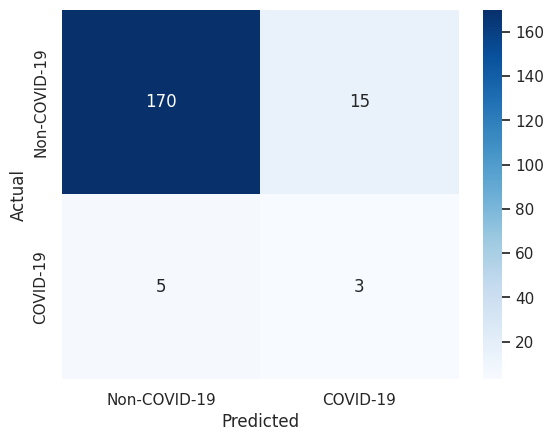

In [ ]:
# Predict on test set
y_pred = clf.predict(X_test.reshape(len(X_test), -1))

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
sns.set()
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', xticklabels=['Non-COVID-19', 'COVID-19'], yticklabels=['Non-COVID-19', 'COVID-19'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

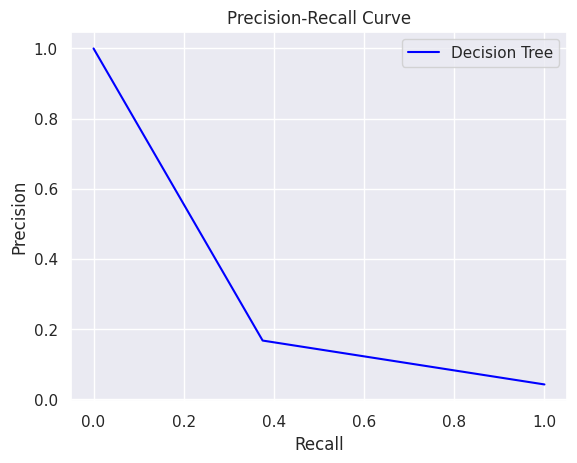

In [ ]:
# Predict on test set
y_pred_proba = clf.predict_proba(X_test.reshape(len(X_test), -1))[:, 1]

# Calculate precision and recall at different thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Plot precision-recall curve
plt.plot(recall, precision, color='blue', label='Decision Tree')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()









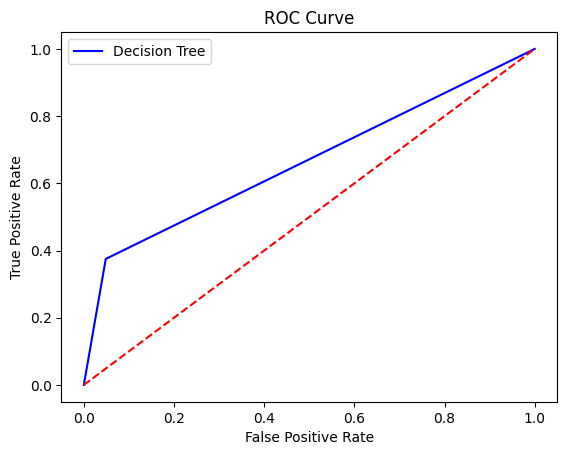

In [ ]:
# Predict on test set
y_pred_proba = clf.predict_proba(X_test.reshape(len(X_test), -1))[:, 1]

# Calculate false positive rate and true positive rate at different thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Plot ROC curve
plt.plot(fpr, tpr, color='blue', label='Decision Tree')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()









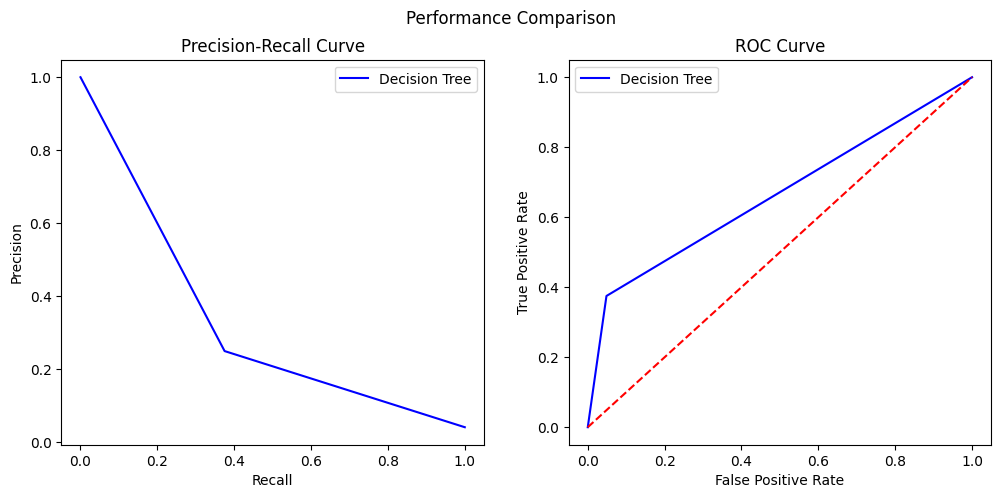

In [ ]:
# Predict on test set
y_pred_proba = clf.predict_proba(X_test.reshape(len(X_test), -1))[:, 1]

# Calculate precision and recall at different thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Calculate false positive rate and true positive rate at different thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Plot both curves side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Performance Comparison')

# Precision-Recall curve
ax1.plot(recall, precision, color='blue', label='Decision Tree')
ax1.set_xlabel('Recall')
ax1.set_ylabel('Precision')
ax1.set_title('Precision-Recall Curve')
ax1.legend()

# ROC curve
ax2.plot(fpr, tpr, color='blue', label='Decision Tree')
ax2.plot([0, 1], [0, 1], color='red', linestyle='--')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend()

plt.show()